# Phase 3 and 4: Ridge Regression Modeling

This notebook uses `final_model_ready_data.csv` for the model building phase.
The main goal is to build a Ridge Regression model, tune it, and save the results for comparison.

We use `random_state=42` so the train/test split can be repeated.

## 1. Import libraries

In this cell, we import the libraries needed for data handling, model training, model tuning, and checking the model result.

In [1]:
# Import the main libraries for this notebook.
# pandas and numpy are used for working with the dataset.
# sklearn is used for splitting data, building the model, and checking performance.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# This random state matches the project setup from Monika.
RANDOM_STATE = 42

## 2. Load the model-ready dataset

Here we load the final dataset that will be used for Phase 3 modeling. This file already combines the cleaned and engineered data.

In [2]:
# Load the final model-ready file.
# This is the dataset Monika said we should use for Phase 3.

df = pd.read_csv("final_model_ready_data.csv")

# Show the first few rows to make sure the file loaded correctly.
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
0,1,4.110874,RL,4.189655,9.042040,Pave,Reg,Lvl,AllPub,Inside,...,False,False,False,False,False,False,False,True,True,False
1,2,3.044522,RL,4.394449,9.169623,Pave,Reg,Lvl,AllPub,FR2,...,False,False,False,False,False,False,False,True,True,False
2,3,4.110874,RL,4.234107,9.328212,Pave,IR1,Lvl,AllPub,Inside,...,False,False,False,False,False,False,False,True,True,False
3,4,4.262680,RL,4.110874,9.164401,Pave,IR1,Lvl,AllPub,Corner,...,False,False,False,False,False,False,False,True,True,False
4,5,4.110874,RL,4.442651,9.565284,Pave,IR1,Lvl,AllPub,FR2,...,False,False,False,False,False,False,False,True,True,False


## 3. Quick dataset check

Before training the model, we check the size of the dataset, the column types, and whether `SalePrice` is available as the target column.

In [3]:
# Check the shape and data types.
# This helps us understand what is inside the file before modeling.

print("Dataset shape:", df.shape)
print("SalePrice column available:", "SalePrice" in df.columns)
print("Total missing values:", df.isna().sum().sum())

print("\nColumn type counts:")
print(df.dtypes.value_counts())

Dataset shape: (1460, 276)
SalePrice column available: True
Total missing values: 2073

Column type counts:
bool       199
object      39
float64     22
int64       16
Name: count, dtype: int64


## 4. Prepare features and target

Ridge Regression needs numeric input. This dataset still has some original text columns, so we keep only numeric and boolean columns for the model.
The boolean columns are the one-hot encoded columns, so we convert them into 0 and 1.

In [4]:
# Separate the target column from the feature columns.
# SalePrice is what the model will try to predict.

target_col = "SalePrice"
id_col = "Id"

y = df[target_col]

# Drop SalePrice because it is the answer, not an input.
# Drop Id because it is only an identifier and should not help predict price.
feature_data = df.drop(columns=[target_col, id_col], errors="ignore")

# Keep only numeric and boolean columns.
# Text columns are not used here because Ridge cannot read text directly.
X = feature_data.select_dtypes(include=["number", "bool"]).copy()

# Convert True/False one-hot columns into 1/0 columns.
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

text_cols = feature_data.select_dtypes(include=["object"]).columns

print("Total feature columns used:", X.shape[1])
print("Boolean one-hot columns converted to 0/1:", len(bool_cols))
print("Text columns not used directly:", len(text_cols))
print("Example text columns not used:", list(text_cols[:10]))

Total feature columns used: 235
Boolean one-hot columns converted to 0/1: 199
Text columns not used directly: 39
Example text columns not used: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2']


## 5. Check missing values in the model features

We check missing values again after selecting the model features. The pipeline will still include a median imputer just in case there are missing values later.

In [5]:
# Check if any model feature has missing values.
# If there are missing values, the model pipeline will fill them with the median.

missing_features = X.isna().sum().sort_values(ascending=False)
missing_features = missing_features[missing_features > 0]

if len(missing_features) == 0:
    print("No missing values in the selected model features.")
else:
    display(missing_features.head(20))

No missing values in the selected model features.


## 6. Train/test split

We split the data into training and testing data. The model learns from the training set, then we test it on data it has not seen before.

In [6]:
# Split the data into training and test sets.
# test_size=0.2 means 20% of the rows are saved for testing.
# random_state=42 keeps the split the same every time.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training rows: 1168
Testing rows: 292
Training features: 235


## 7. Create an evaluation helper

This function calculates the same metrics for each model. We use RMSE, MAE, and R² so the models are easier to compare.

In [7]:
# This function keeps the model evaluation clean and consistent.
# RMSE and MAE are in house price units.
# R2 shows how much variation in SalePrice the model explains.

def evaluate_model(model_name, y_true, y_pred, best_alpha=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Best Alpha": best_alpha
    }

model_results = []

## 8. Baseline model

We start with a very simple baseline model. It predicts the average house price for every house. The Ridge model should do much better than this.

In [8]:
# Baseline model: always predicts the average SalePrice from the training data.
# This gives a simple score to compare against.

baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
model_results.append(evaluate_model("Baseline Mean Model", y_test, baseline_pred))

pd.DataFrame(model_results)

,Model,RMSE,MAE,R2,Best Alpha
0,Baseline Mean Model,87619.034506,62575.926452,-0.000882,None


## 9. First Ridge Regression model

Now we train a basic Ridge Regression model with `alpha=1`. We scale the features because Ridge Regression is affected by feature size.

In [9]:
# Ridge Regression works better when features are scaled.
# The pipeline first fills missing values, then scales features, then trains Ridge.

ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)

model_results.append(evaluate_model("Ridge Regression alpha=1", y_test, ridge_pred, best_alpha=1.0))

pd.DataFrame(model_results).sort_values("RMSE")

,Model,RMSE,MAE,R2,Best Alpha
1,Ridge Regression alpha=1,40432.785117,21004.922605,0.786866,1.0
0,Baseline Mean Model,87619.034506,62575.926452,-0.000882,NaN


## 10. Tune Ridge alpha

The `alpha` value controls how strong the Ridge penalty is. We test several alpha values with cross-validation and keep the best one.

In [10]:
# Try different alpha values for Ridge.
# Small alpha means less regularization, large alpha means stronger regularization.

alpha_values = np.logspace(-3, 3, 25)

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"ridge__alpha": alpha_values},
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_["ridge__alpha"]
best_ridge_pred = best_ridge.predict(X_test)

model_results.append(
    evaluate_model("Tuned Ridge Regression", y_test, best_ridge_pred, best_alpha=best_ridge_alpha)
)

print("Best alpha for normal Ridge:", best_ridge_alpha)
print("Best cross-validation RMSE:", np.sqrt(-ridge_grid.best_score_))

pd.DataFrame(model_results).sort_values("RMSE")

Best alpha for normal Ridge: 316.22776601683796
Best cross-validation RMSE: 33050.12151591077


,Model,RMSE,MAE,R2,Best Alpha
2,Tuned Ridge Regression,33519.436759,20144.414085,0.853520,316.227766
1,Ridge Regression alpha=1,40432.785117,21004.922605,0.786866,1.000000
0,Baseline Mean Model,87619.034506,62575.926452,-0.000882,NaN


## 11. Improvement: use log SalePrice

House prices are usually skewed because a few expensive houses can be much higher than the rest. As an improvement, we train Ridge on `log(SalePrice)` and then convert predictions back to normal prices.

In [11]:
# This is the improved version.
# The model learns log prices, then we convert predictions back with expm1.
# This often helps because house prices are not evenly distributed.

log_ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(random_state=RANDOM_STATE))
])

log_ridge_grid = GridSearchCV(
    estimator=log_ridge_pipeline,
    param_grid={"ridge__alpha": alpha_values},
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

log_ridge_grid.fit(X_train, np.log1p(y_train))

best_log_ridge = log_ridge_grid.best_estimator_
best_log_alpha = log_ridge_grid.best_params_["ridge__alpha"]

log_ridge_pred = np.expm1(best_log_ridge.predict(X_test))
log_ridge_pred = np.maximum(log_ridge_pred, 0)

model_results.append(
    evaluate_model("Tuned Ridge with Log Target", y_test, log_ridge_pred, best_alpha=best_log_alpha)
)

print("Best alpha for log-target Ridge:", best_log_alpha)
print("Best cross-validation RMSE on log scale:", np.sqrt(-log_ridge_grid.best_score_))

results_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
results_df

Best alpha for log-target Ridge: 177.82794100389228
Best cross-validation RMSE on log scale: 0.13871171056952833


,Model,RMSE,MAE,R2,Best Alpha
0,Tuned Ridge with Log Target,26349.396179,16231.198178,0.909484,177.827941
1,Tuned Ridge Regression,33519.436759,20144.414085,0.853520,316.227766
2,Ridge Regression alpha=1,40432.785117,21004.922605,0.786866,1.000000
3,Baseline Mean Model,87619.034506,62575.926452,-0.000882,NaN


## 12. Visual check of the best model

Here we compare the actual prices with the predicted prices from the best model. If the model is good, the points should be close to the diagonal line.

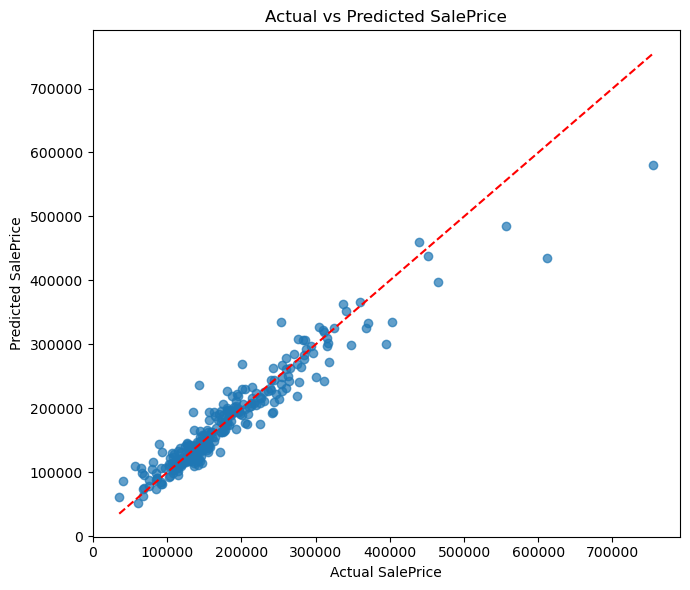

In [12]:
# Pick the best model based on the lowest RMSE.
# In this notebook, the log-target Ridge model is expected to perform best.

best_model_name = "Tuned Ridge with Log Target"
best_predictions = log_ridge_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.tight_layout()
plt.show()

## 13. Residual check

Residuals are the difference between actual price and predicted price. This helps us see whether the model is making very large errors for some houses.

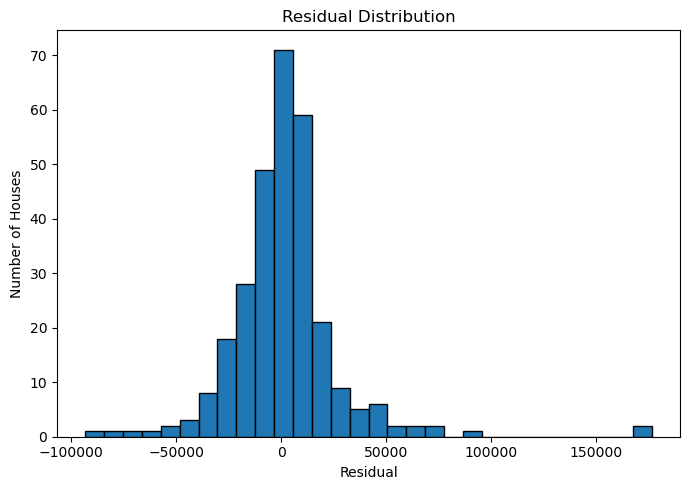

Average residual: 1773.7286608603656
Median residual: 1182.3537366532837


In [13]:
# Calculate residuals.
# Positive residual means the actual price was higher than the prediction.
# Negative residual means the prediction was higher than the actual price.

residuals = y_test - best_predictions

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Number of Houses")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

print("Average residual:", residuals.mean())
print("Median residual:", residuals.median())

## 14. Check important coefficients

Ridge coefficients can show which features are linked with higher or lower predicted prices. Since the model uses scaled features, these are useful for direction and comparison, not exact dollar amounts.

In [14]:
# Get coefficients from the best log-target Ridge model.
# Positive coefficients are linked with higher predicted prices.
# Negative coefficients are linked with lower predicted prices.

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_log_ridge.named_steps["ridge"].coef_
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

print("Top positive coefficients:")
display(coef_df.sort_values("Coefficient", ascending=False).head(10))

print("Top negative coefficients:")
display(coef_df.sort_values("Coefficient", ascending=True).head(10))

Top positive coefficients:


,Feature,Coefficient,Absolute Coefficient
15,GrLivArea,0.057748,0.057748
3,OverallQual,0.052932,0.052932
12,1stFlrSF,0.038594,0.038594
4,OverallCond,0.030848,0.030848
2,LotArea,0.027120,0.027120
25,GarageCars,0.025458,0.025458
197,Neighborhood_NridgHt,0.022280,0.022280
5,YearBuilt,0.020727,0.020727
6,YearRemodAdd,0.020478,0.020478
203,Neighborhood_StoneBr,0.020201,0.020201


Top negative coefficients:


,Feature,Coefficient,Absolute Coefficient
58,BsmtQual_TA,-0.020750,0.020750
71,Condition2_PosN,-0.017684,0.017684
163,KitchenQual_TA,-0.017238,0.017238
188,Neighborhood_Edwards,-0.016652,0.016652
162,KitchenQual_Gd,-0.014250,0.014250
57,BsmtQual_Gd,-0.013510,0.013510
124,Functional_Maj2,-0.013423,0.013423
151,Heating_Grav,-0.012905,0.012905
191,Neighborhood_MeadowV,-0.012562,0.012562
21,KitchenAbvGr,-0.012457,0.012457


## 15. Save model results and predictions

We save the model comparison table and the test-set predictions. These files can be used later for the project write-up or Tableau/storytelling phase.

In [15]:
# Save model scores.
# Save predictions from the best model so we can inspect or visualize them later.

results_df.to_csv("ridge_regression_model_results.csv", index=False)

predictions_df = pd.DataFrame({
    "Id": df.loc[X_test.index, "Id"] if "Id" in df.columns else X_test.index,
    "ActualSalePrice": y_test,
    "PredictedSalePrice": best_predictions,
    "Residual": residuals
})

predictions_df.to_csv("ridge_regression_predictions.csv", index=False)

print("Saved ridge_regression_model_results.csv")
print("Saved ridge_regression_predictions.csv")

predictions_df.head()

Saved ridge_regression_model_results.csv
Saved ridge_regression_predictions.csv


,Id,ActualSalePrice,PredictedSalePrice,Residual
892,893,154500,150653.747611,3846.252389
1105,1106,325000,325952.570913,-952.570913
413,414,115000,102721.473011,12278.526989
522,523,159000,163364.347573,-4364.347573
1036,1037,315500,310690.965759,4809.034241
